# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Abraham Cano"            # Tu nombre completo
MATRICULA = "81505"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "desnutricion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Abraham Cano
Matrícula: 81505
Dataset asignado: desnutricion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


/Users/abrahamcv/Desktop/bigdata/.venv/bin/python


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2001,9400000.0
1,Afghanistan,AFG,2002,9300000.0
2,Afghanistan,AFG,2003,8700000.0
3,Afghanistan,AFG,2004,8200000.0
4,Afghanistan,AFG,2005,7500000.0
5,Afghanistan,AFG,2006,6700000.0
6,Afghanistan,AFG,2007,5900000.0
7,Afghanistan,AFG,2008,5200000.0
8,Afghanistan,AFG,2009,4800000.0
9,Afghanistan,AFG,2010,5000000.0


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(3544, 4)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   str    
 1   code    2758 non-null   str    
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 110.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity      0
code      786
year        0
valor       0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*(Escribe aquí tu respuesta)*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
# Pregunta 1
# Tu codigo aqui
df_paises = df[df[config['filtro_paises']].notnull()]

num_paises = df_paises['entity'].nunique()
print("Número de países distintos:", num_paises)

df_limpio = df_paises.dropna(subset=['valor'])

top_10_mayor = df_limpio.sort_values('valor', ascending=False).head(10)
print("10 países con MAYOR valor")
display(top_10_mayor[['entity', 'year', 'valor']])

top_10_menor = df_limpio.sort_values('valor', ascending=True).head(10)
print("10 países con MENOR valor")
display(top_10_menor[['entity', 'year', 'valor']])


Número de países distintos: 140
10 países con MAYOR valor


,entity,year,valor
3475,World,2002,825200000.0
3477,World,2004,818600000.0
3476,World,2003,817900000.0
3474,World,2001,802700000.0
3478,World,2005,788800000.0
3473,World,2000,781100000.0
3479,World,2006,733800000.0
3494,World,2021,697500000.0
3495,World,2022,695200000.0
3496,World,2023,688400000.0


10 países con MENOR valor


,entity,year,valor
457,Cape Verde,2017,100000.0
1092,French Polynesia,2012,100000.0
813,Dominica,2006,100000.0
812,Dominica,2005,100000.0
811,Dominica,2004,100000.0
810,Dominica,2003,100000.0
809,Dominica,2002,100000.0
1093,French Polynesia,2013,100000.0
808,Dominica,2001,100000.0
1091,French Polynesia,2011,100000.0


**Interpretación:**

*Al aplicar el filtro se identificaron 140 países distintos. En los resultados con mayor valor se observa que la entidad el total mundial ocupa  los primeros lugares del ranking, es decir que el filtro de la base de datos no descartó el agregado global. Los registros con menor valor son de naciones  muy pequeñas, como Dominica, Cabo Verde y la Polinesia Francesa.*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2
# Tu codigo aqui
paises = ['Mexico', 'Brazil']
df_p2 = df_paises[df_paises['entity'].isin(paises)].dropna(subset=['valor'])
display(df_p2[['entity', 'year', 'valor']])


,entity,year,valor
338,Brazil,2001,18400000.0
339,Brazil,2002,16200000.0
340,Brazil,2003,13800000.0
341,Brazil,2004,11500000.0
342,Brazil,2005,10500000.0
343,Brazil,2006,9400000.0
344,Brazil,2007,8500000.0
345,Brazil,2008,7600000.0
346,Brazil,2009,6700000.0
347,Brazil,2010,5800000.0


**Interpretación:**

*Elegí México y Brasil, y se puede ver que ambos países presentan situaciones distintas. Por ejemplo, México ha tenido un incremento sutil y de cierto modo estable en todos sus registros, mientras que Brasil inició con valores muy altos y logró reducirlos. Esto se puede deber al incremento en el poder económico del país y que su situación actual le ha permitido mejorar sus indices y oportunidades para sus habitantes.*

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [12]:
# Pregunta 3
# Tu codigo aqui
paises_5 = ['Mexico', 'Nigeria', 'India', 'France', 'Australia']

df_p3 = df_paises[df_paises['entity'].isin(paises_5)].dropna(subset=['valor'])
df_reciente_p3 = df_p3.sort_values('year', ascending=False).drop_duplicates(subset='entity')

display(df_reciente_p3[['entity', 'year', 'valor']])

maximo = df_reciente_p3['valor'].max()
minimo = df_reciente_p3['valor'].min()
diferencia = maximo - minimo

print("Valor más alto:", maximo)
print("Valor más bajo:", minimo)
print("Diferencia:", diferencia)


,entity,year,valor
2260,Nigeria,2023,45400000.0
1986,Mexico,2023,3500000.0
1360,India,2023,172100000.0


Valor más alto: 172100000.0
Valor más bajo: 3500000.0
Diferencia: 168600000.0


**Interpretación:**

*Se puede observar como de entre los paises seleccionados, México fue el que obtuvo el valor más bajo, mientras Nigeria el más alto, demostrando la enorme brecha en la diferencia que existe entre ambos datos.*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [13]:
# Pregunta 4
# Tu codigo aqui
latam = ['Mexico', 'Colombia', 'Argentina']
asia = ['China', 'Japan', 'Vietnam']

df_reciente_global = df_paises.dropna(subset=['valor']).sort_values('year', ascending=False).drop_duplicates(subset='entity')
promedio_latam = df_reciente_global[df_reciente_global['entity'].isin(latam)]['valor'].mean()
promedio_asia = df_reciente_global[df_reciente_global['entity'].isin(asia)]['valor'].mean()

print("Promedio Latinoamérica:", promedio_latam)
print("Promedio Asia:", promedio_asia)

Promedio Latinoamérica: 2333333.3333333335
Promedio Asia: 21900000.0


**Interpretación:**

*Podemos observar como en promedio, latinoamerica presenta un mayor indice de personas desnutridas que en Asia, esto apegandose a los diferentes contextos economicos que cada región enfrenta.*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [14]:
# Pregunta 5
# Tu codigo aqui

df_mexico_p5 = df_paises[df_paises['entity'] == 'Mexico'].dropna(subset=['valor'])

maximo_mex = df_mexico_p5['valor'].max()
minimo_mex = df_mexico_p5['valor'].min()

anio_max = df_mexico_p5[df_mexico_p5['valor'] == maximo_mex]['year'].values[0]
anio_min = df_mexico_p5[df_mexico_p5['valor'] == minimo_mex]['year'].values[0]

print("Valor máximo:", maximo_mex, "en el año", anio_max)
print("Valor mínimo:", minimo_mex, "en el año", anio_min)


Valor máximo: 4600000.0 en el año 2009
Valor mínimo: 2800000.0 en el año 2001


**Interpretación:**

*Tomando en cuenta que el valor máximo obtenido fue en el 2009, y el dataset abarca hasta aproximadamente el 2024, la tendencia ha sido fluctuante, manteniendose apegada a valores que eran proyectados.*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [15]:
# Pregunta 6
# Tu codigo aqui
df_mexico_p6 = df_paises[df_paises['entity'] == 'Mexico'].dropna(subset=['valor']).sort_values('year')

valor_inicial = df_mexico_p6.iloc[0]['valor']
valor_final = df_mexico_p6.iloc[-1]['valor']

cambio_pct = ((valor_final - valor_inicial) / valor_inicial) * 100

print("Valor primer año:", valor_inicial)
print("Valor último año:", valor_final)
print("Cambio porcentual: {:.2f}%".format(cambio_pct))

Valor primer año: 2800000.0
Valor último año: 3500000.0
Cambio porcentual: 25.00%


**Interpretación:**

*La información presenta un incremento relativo, esto puede deberse a varios factores, desde el incremento del costo de vida en el país hasta el aumento de la población en el mismo. Sumado a los cambios de gobierno e inversiones realziadas en el país, puede influir en el poder económico de una persona.*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [16]:
# Pregunta 7
# Tu codigo aqui

import numpy as np

valores_recientes = df_reciente_global['valor']

media = np.mean(valores_recientes)
mediana = np.median(valores_recientes)
desviacion = np.std(valores_recientes)

print("Media global reciente:", media)
print("Mediana global reciente:", mediana)
print("Desviación estándar global reciente:", desviacion)


Media global reciente: 9781428.57142857
Mediana global reciente: 900000.0
Desviación estándar global reciente: 58539520.94307655


**Interpretación:**

*Dada la gran diferencia entre la media y la mediana obtenida, podemos decir que algunos paises (principalmente aquellos con mayores indices de poblacion) influyen en mayor medida a la estadistica aplciada que se hace en los datos.*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

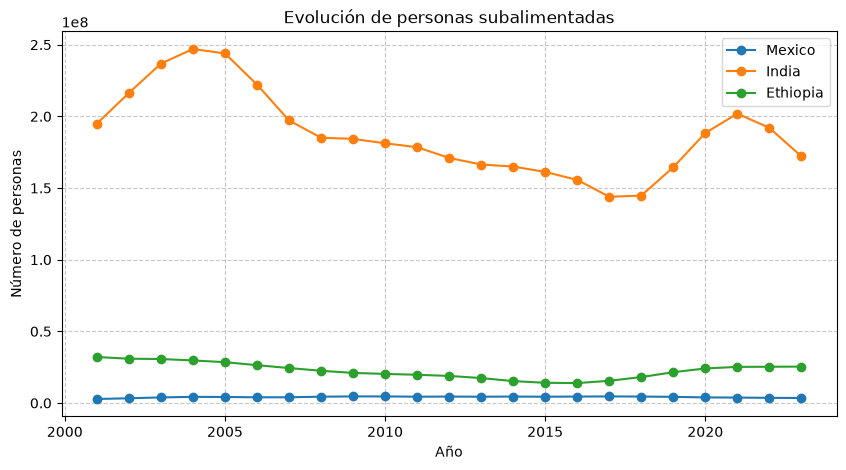

In [17]:
# Pregunta 8
# Tu codigo aqui

paises_3 = ['Mexico', 'India', 'Ethiopia']

plt.figure(figsize=(10, 5))

for p in paises_3:
    df_temp = df_paises[df_paises['entity'] == p].dropna(subset=['valor']).sort_values('year')
    plt.plot(df_temp['year'], df_temp['valor'], marker='o', label=p)

plt.title("Evolución de personas subalimentadas")
plt.xlabel("Año")
plt.ylabel("Número de personas")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Interpretación:**

*Podemos observar como para México y Ethiopia, la gráfica demuestra flujos y proyecciones muhco más estables, sin picos notorios o alarmantes, demostrando un mayor control en la proyección de los datos. Por otro lado, en la India se notan sus picos de manera más clara, esto principalmente debido a la abismal diferencia en el número de la poblacion que existe entre los tres países, haciendo más compleja la estadistica aplicada y la interpretación de los datos.*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

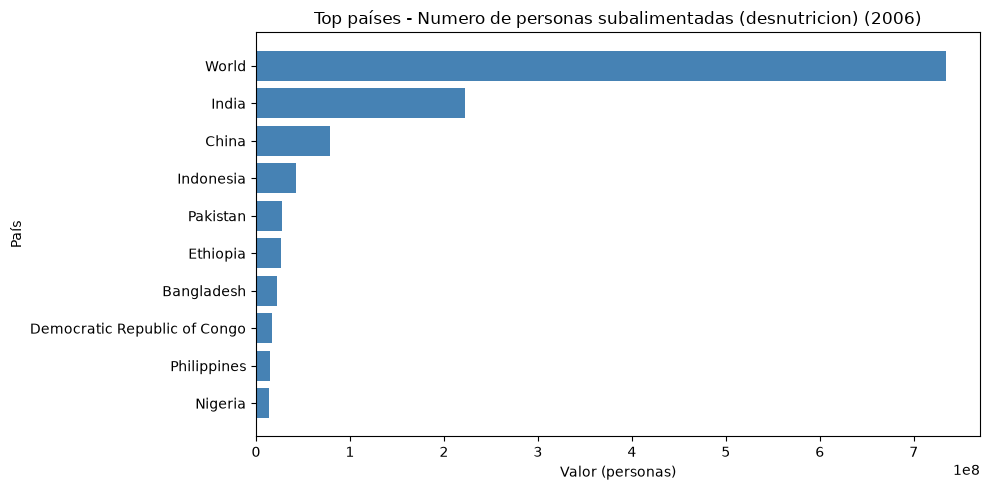

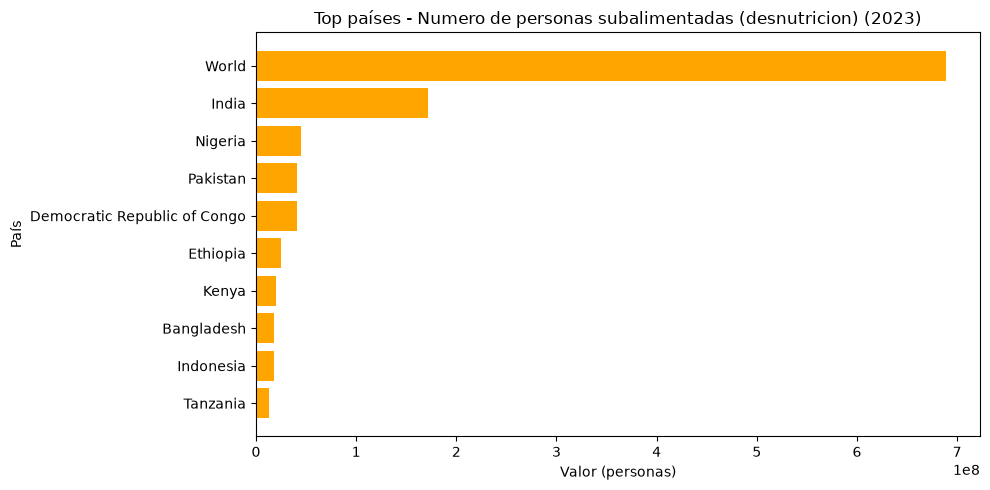

In [18]:
# Pregunta 9
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_nacimiento = 2006  

top_nacimiento = (
    df_paises[df_paises['year'] == anio_nacimiento]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_nacimiento['entity'], top_nacimiento['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_nacimiento})")

plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

anio_reciente = 2023

top_reciente = (
    df_paises[df_paises['year'] == anio_reciente]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_reciente['entity'], top_reciente['valor'], color='orange')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_reciente})")

plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

**Interpretación:**

*Podemos observar en las gráficas que el país con el mayor número de desnutrición entre el 2006 y el 2023 es la India, mencionando nuevamente que se debe a su gran número de población que tiene. Aunque es importante mencionar que entre los datos se visualiza un decremento en el numero de personas, siendo menor en el 2023 mostrando una mejoría. Además, China logró desaparecer del ranking, siendo esto coherente con la evolución económica e influencia que el país ha conseguido en la última decada, disminuyendo su tasa de desnutrición; otros países como Nigeria y Pakistan subieron en el ranking.*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*Al concluir la práctica pude visualizar la importancia del filtrado de datos y de la preparación de los mismos, ya que en muchas ocasiones los registros incluyen valores nulos o vacíos, influyendo en las operaciones o trabajo que se quiera realizar con los datos. Además, fue notorio que al no trabajar con porcentajes, los países con mayor numero poblacional dominaban la lista de aquellos que presentaban indices de desnutrición. Quizá sería interesante trabajar con procentajes y datos reales para aplicarlo a un contexto realista y no un poco cegado a los numeros altos de poblacion que algunos paises pueden tener, como la India.*

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
